<a href="https://colab.research.google.com/github/philipassadaziz-2002/fuzzy-factory-analytics/blob/main/Data_Preprocessing_for_Fuzzy_Factory_Orders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Importing Libraries

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import pandas as pd #dataframe
from matplotlib import pyplot as plt
import seaborn as sns

### 2. Importing and Exploration of the dataset

In [4]:
# loading the data
df= pd.read_csv('/content/orders.csv')

In [5]:
df.head()# # showing the first 5 rows of the dataset:

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49


In [6]:
# To check the Dimensions of the dataset:
df.shape

(32313, 8)

In [7]:
# Checking the info of the data:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32313 entries, 0 to 32312
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            32313 non-null  int64  
 1   created_at          32313 non-null  object 
 2   website_session_id  32313 non-null  int64  
 3   user_id             32313 non-null  int64  
 4   primary_product_id  32313 non-null  int64  
 5   items_purchased     32313 non-null  int64  
 6   price_usd           32313 non-null  float64
 7   cogs_usd            32313 non-null  float64
dtypes: float64(2), int64(5), object(1)
memory usage: 2.0+ MB


### 3.Filtering Data

Example: filter high order prices

In [8]:
df['price_usd'].mean()

np.float64(59.99163649305234)

In [9]:
high_price= df[df['price_usd']> df['price_usd'].mean()]

high_price.head()

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
7299,7300,2013-09-25 08:49:13,132876,116186,1,2,109.98,41.98
7301,7302,2013-09-25 12:50:39,132965,116266,1,2,109.98,41.98
7309,7310,2013-09-25 17:30:15,133099,116378,1,2,109.98,41.98
7351,7352,2013-09-27 01:40:13,133588,103416,2,2,109.98,41.98
7375,7376,2013-09-28 10:21:27,133996,88820,1,2,109.98,41.98


### 4. Converting the data types of columns

    - order_id to object
    - primary_product_id to category dtype
    - created_at to date type

In [10]:
df.dtypes

,0
order_id,int64
created_at,object
website_session_id,int64
user_id,int64
primary_product_id,int64
items_purchased,int64
price_usd,float64
cogs_usd,float64


In [11]:
df['order_id']=df['order_id'].astype('object')

df['primary_product_id']=df['primary_product_id'].astype('category')

In [12]:
df['created_at']=pd.to_datetime(df['created_at'],format='%Y-%m-%d %H:%M:%S')


df.head()

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49


#### Checking the datatypes again:

In [13]:
df.dtypes

,0
order_id,object
created_at,datetime64[ns]
website_session_id,int64
user_id,int64
primary_product_id,category
items_purchased,int64
price_usd,float64
cogs_usd,float64


### 5. Summary Statistics of the data

In [14]:
# Numerical summary
summary_stats = df.describe()
print(summary_stats)

# Categorical summary
categorical_summary = df.describe(include='object')
print(categorical_summary)

                          created_at  website_session_id        user_id  \
count                          32313        32313.000000   32313.000000   
mean   2014-04-14 03:01:01.276823552       258292.288707  215691.622629   
min              2012-03-19 10:42:46           20.000000      13.000000   
25%              2013-10-30 14:30:35       144828.000000  124135.000000   
50%              2014-06-11 14:27:02       263554.000000  221461.000000   
75%              2014-11-28 10:53:48       374799.000000  310542.000000   
max              2015-03-19 05:38:31       472818.000000  394273.000000   
std                              NaN       132427.649842  108402.203189   

       items_purchased     price_usd      cogs_usd  
count     32313.000000  32313.000000  32313.000000  
mean          1.238666     59.991636     22.355406  
min           1.000000     29.990000      9.490000  
25%           1.000000     49.990000     19.490000  
50%           1.000000     49.990000     19.490000  
75%   

### 6. Missing Values

In [15]:
# use isnull().sum() to check for missing values
df.isna().sum()

,0
order_id,0
created_at,0
website_session_id,0
user_id,0
primary_product_id,0
items_purchased,0
price_usd,0
cogs_usd,0


### 7.Filtering Data (Focus on Trends)

Example: filter high order prices

In [16]:
high_prices = df[df['price_usd'] > df['price_usd'].mean()]
print(high_prices.head())

     order_id          created_at  website_session_id  user_id  \
7299     7300 2013-09-25 08:49:13              132876   116186   
7301     7302 2013-09-25 12:50:39              132965   116266   
7309     7310 2013-09-25 17:30:15              133099   116378   
7351     7352 2013-09-27 01:40:13              133588   103416   
7375     7376 2013-09-28 10:21:27              133996    88820   

     primary_product_id  items_purchased  price_usd  cogs_usd  
7299                  1                2     109.98     41.98  
7301                  1                2     109.98     41.98  
7309                  1                2     109.98     41.98  
7351                  2                2     109.98     41.98  
7375                  1                2     109.98     41.98  


### 8.Grouping Data (Pattern Discovery)

Identify trends across categories

In [17]:
price_by_product = df.groupby('primary_product_id')['price_usd'].mean()
print(price_by_product)

primary_product_id
1    59.501606
2    66.231351
3    58.949488
4    34.037384
Name: price_usd, dtype: float64


/tmp/ipykernel_3685/1312372337.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_by_product = df.groupby('primary_product_id')['price_usd'].mean()


### 9. Outliers Treatment

To check for the presence of outliers, we plot Boxplot.

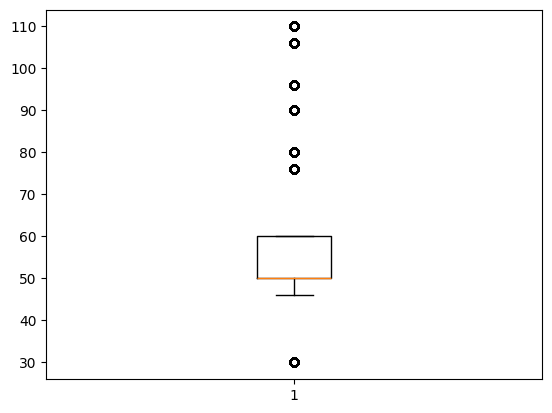

In [18]:
# For price_usd
plt.boxplot(df['price_usd'])
plt.show()

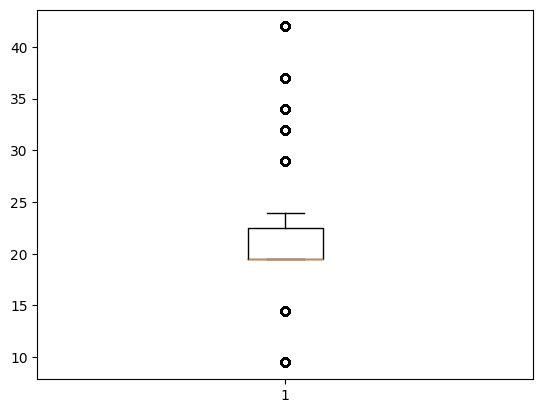

In [19]:
# For cogs_usd
plt.boxplot(df['cogs_usd'])
plt.show()

### 10.Correlation Analysis

Find relationships between numerical variables

In [20]:
# Select numeric columns only
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
correlation_matrix = numeric_df.corr()
print(correlation_matrix)

                    website_session_id   user_id  items_purchased  price_usd  \
website_session_id            1.000000  0.995541         0.307282   0.251952   
user_id                       0.995541  1.000000         0.307907   0.253193   
items_purchased               0.307282  0.307907         1.000000   0.919901   
price_usd                     0.251952  0.253193         0.919901   1.000000   
cogs_usd                      0.195306  0.196819         0.864138   0.981532   

                    cogs_usd  
website_session_id  0.195306  
user_id             0.196819  
items_purchased     0.864138  
price_usd           0.981532  
cogs_usd            1.000000  


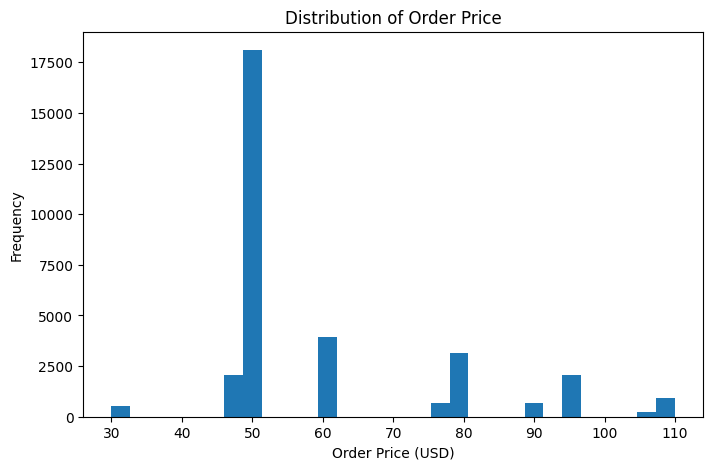

In [21]:
plt.figure(figsize=(8, 5))
plt.hist(df['price_usd'], bins=30)
plt.xlabel('Order Price (USD)')
plt.ylabel('Frequency')
plt.title('Distribution of Order Price')
plt.show()

In [22]:
%pip install ydata-profiling
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Orders Data Report")
profile.to_file("orders_data_report.html")
profile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.9 MB/s eta 0:00:00


/tmp/ipykernel_3685/4069385799.py:2: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 21.55it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]